# Blocco 0: Importazioni e setup ambiente
- importazione delle librerie necessarie:
1. TensorFlow/Keras, 
2. Pandas, 
3. NumPy, 
4. Matplotlib, 
5. Scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Impostiamo il 


### Blocco 1: Caricamento, filtraggio e pre-elaborazione del DatasetAssicurati di avere i file sign_mnist_train.csv e sign_mnist_test.csv nella stessa cartella del notebook (o aggiorna i percorsi).

- In questo step:
1. Carichiamo train e test set da CSV.
2. Filtriamo per le prime 5 classi (A=0, B=1, C=2, D=3, E=4).
3. Normalizziamo i pixel nell'intervallo $[0, 1]$.
4. Eseguiamo uno split di validation sul train set ($80%$ train, $20%$ validation)

In [8]:
# 1 Caricahimo file CSV
train_df = pd.read_csv('sign_mnist_train.csv')
test_df = pd.read_csv('sign_mnist_test.csv')

# 2 FIltraggio: consideriamo solo le prime 5 classi (0=A, 1=B, 2=C, 3=D, 4=E)

# crea una copia della 5 classi pulita in memoria
train_filtred = train_df[train_df['label'] < 5].copy()
test_filtred = test_df[test_df['label'] < 5].copy()

# Separazione target (label) e feature (pixel)
X_train_raw =  train_filtred.drop(columns=['label']).values
y_train_raw = train_filtred['label'].values

X_test_raw = test_filtred.drop(columns=['label']).values
y_test = test_filtred['label'].values

# 3 Normalizzazione [0, 1]

X_train_norm = X_train_raw / 255.0
X_test = X_test_norm = X_test_raw / 255.0

# 4. Train-Validation Split (80% train, 20% validation)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_norm, y_train_raw, test_size=0.02, random_state=42, stratify=y_train_raw
    )

print(f"Dimensioni Addestramento: {X_train.shape}, Etichette Addestramento: {y_train.shape}")
print(f"Dimensioni Validazione: {X_val.shape}, Etichette Validazione: {y_val.shape}")
print(f"Dimensioni Test: {X_test.shape}, Etichette Test: {y_test.shape}")

Dimensioni Addestramento: (5324, 784), Etichette Addestramento: (5324,)
Dimensioni Validazione: (109, 784), Etichette Validazione: (109,)
Dimensioni Test: (1816, 784), Etichette Test: (1816,)


### locco 2: Progettazione e addestramento ANN (Artificial Neural Network)

- Per l'ANN testiamo 3 configurazioni con diverse tecniche di regolarizzazione (Dropout, L2, Early Stopping) e ottimizzatore Adam (scelto per la sua convergenza rapida ed stabilità sui gradienti grazie ai momenti di primo e secondo ordine).

In [9]:
# --- CONFIGURAZIONE 1: Rete Profonda con Batch Normalization e Dropout ---
ann_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(5, activation='softmax')
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_1 = ann_model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=64, 
    validation_data=(X_val, y_val)
)

# Salva il modello e la miglior accuracy di validation
best_ann_model_1 = ann_model
val_acc_1 = max(history_ann_1.history['val_accuracy'])
print(f"\nAccuratezza Validazione Configurazione 1: {val_acc_1:.4f}")

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9083 - loss: 0.2699 - val_accuracy: 0.9083 - val_loss: 0.5172
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9874 - loss: 0.0465 - val_accuracy: 0.8349 - val_loss: 0.3740
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9884 - loss: 0.0386 - val_accuracy: 0.8073 - val_loss: 0.4141
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9816 - loss: 0.0519 - val_accuracy: 0.5688 - val_loss: 1.0881
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9874 - loss: 0.0370 - val_accuracy: 0.7706 - val_loss: 0.5697
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9853 - loss: 0.0460 - val_accuracy: 0.4954 - val_loss: 3.6991
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9842 - loss: 0.0435 - val_accuracy: 0.6789 - val_loss: 1.1825
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9872 - loss: 0.0351 - val_accuracy: 0.7982 - val_loss:

### Metriche tramite grafico

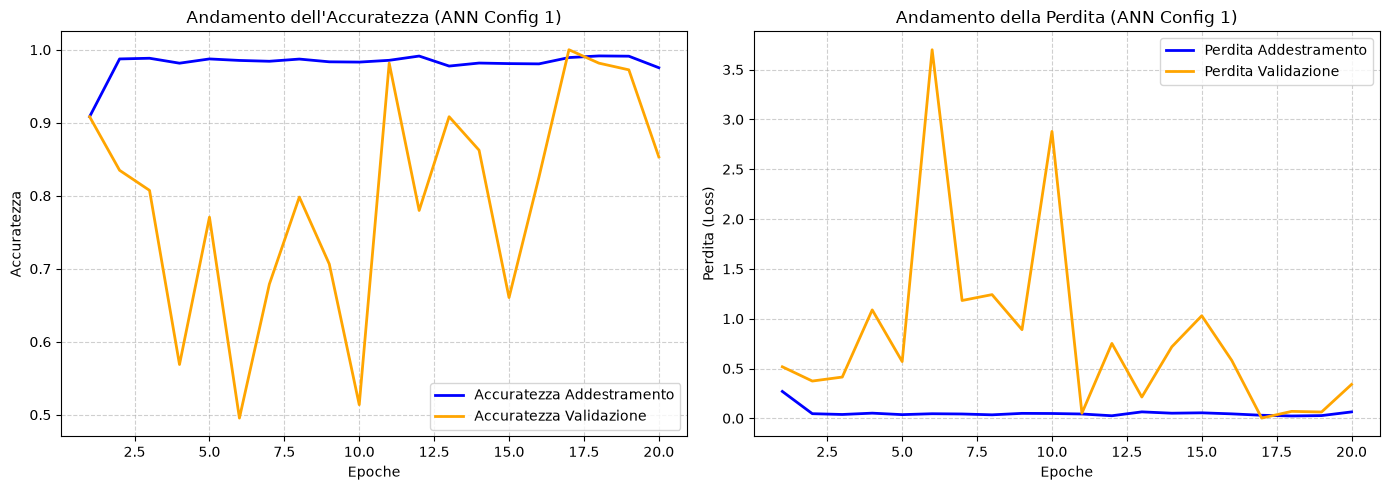

In [10]:
import matplotlib.pyplot as plt

# Estrazione dei dati di accuratezza e loss dalla storia dell'addestramento
acc = history_ann_1.history['accuracy']
val_acc = history_ann_1.history['val_accuracy']
loss = history_ann_1.history['loss']
val_loss = history_ann_1.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Creazione della figura con due grafici affiancati
plt.figure(figsize=(14, 5))

# Grafico 1: Accuratezza (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuratezza Addestramento', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Accuratezza Validazione', color='orange', linewidth=2)
plt.title('Andamento dell\'Accuratezza (ANN Config 1)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perdita Addestramento', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Perdita Validazione', color='orange', linewidth=2)
plt.title('Andamento della Perdita (ANN Config 1)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Perdita (Loss)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Configurazione 2: Rete Media con Regolarizzazione L2

In [11]:
# --- CONFIGURAZIONE 2: Rete Media con Regolarizzazione L2 e Dropout ---
ann_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(5, activation='softmax')
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_2 = ann_model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=64, 
    validation_data=(X_val, y_val)
)

# Salva il modello e la miglior accuracy di validation
best_ann_model_2 = ann_model
val_acc_2 = max(history_ann_2.history['val_accuracy'])
print(f"\nAccuratezza Validazione Configurazione 2: {val_acc_2:.4f}")

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6243 - loss: 1.3614 - val_accuracy: 0.9266 - val_loss: 0.6267
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9082 - loss: 0.5901 - val_accuracy: 0.9541 - val_loss: 0.4339
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9632 - loss: 0.3942 - val_accuracy: 1.0000 - val_loss: 0.2860
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9812 - loss: 0.3197 - val_accuracy: 1.0000 - val_loss: 0.2779
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9805 - loss: 0.2963 - val_accuracy: 1.0000 - val_loss: 0.2245
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9964 - loss: 0.2346 - val_accuracy: 1.0000 - val_loss: 0.2109
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9985 - loss: 0.2133 - val_accuracy: 1.0000 - val_loss: 0.1926
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9880 - loss: 0.2254 - val_accuracy: 1.0000 - val_loss:

### Grafico metriche

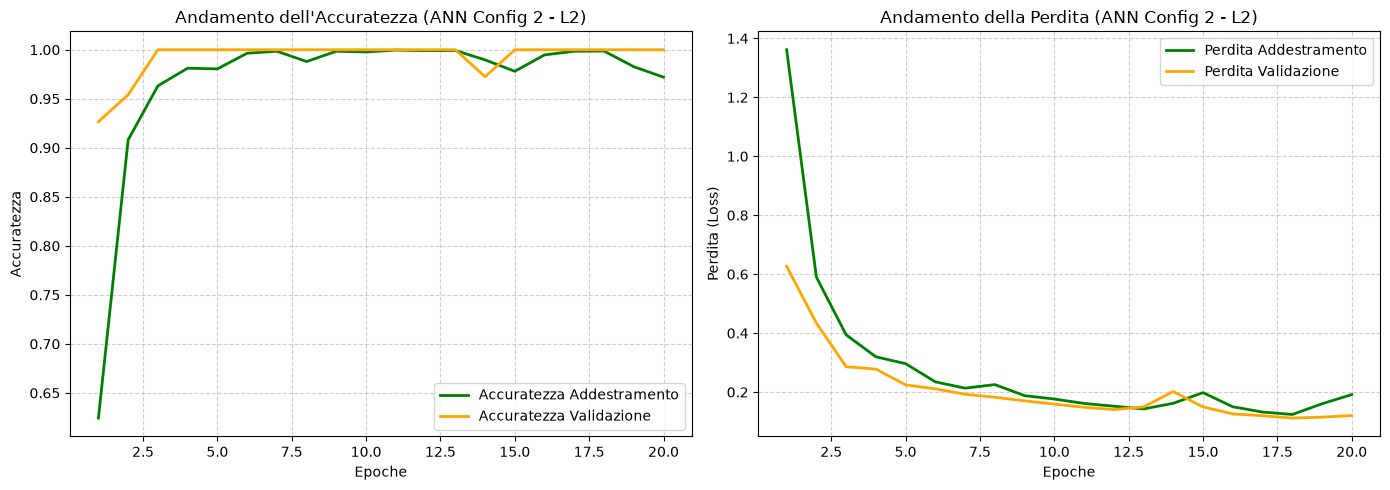

In [13]:
import matplotlib.pyplot as plt

# Estrazione dei dati dalla storia dell'addestramento della Configurazione 2
acc_2 = history_ann_2.history['accuracy']
val_acc_2_list = history_ann_2.history['val_accuracy']
loss_2 = history_ann_2.history['loss']
val_loss_2 = history_ann_2.history['val_loss']

epochs_range = range(1, len(acc_2) + 1)

# Creazione della figura con due grafici affiancati
plt.figure(figsize=(14, 5))

# Grafico 1: Accuratezza (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_2, label='Accuratezza Addestramento', color='green', linewidth=2)
plt.plot(epochs_range, val_acc_2_list, label='Accuratezza Validazione', color='orange', linewidth=2)
plt.title('Andamento dell\'Accuratezza (ANN Config 2 - L2)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_2, label='Perdita Addestramento', color='green', linewidth=2)
plt.plot(epochs_range, val_loss_2, label='Perdita Validazione', color='orange', linewidth=2)
plt.title('Andamento della Perdita (ANN Config 2 - L2)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Perdita (Loss)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [12]:
# --- CONFIGURAZIONE 3: Rete Compatta con Learning Rate ridotto ---
ann_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.1),
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    
    tf.keras.layers.Dense(5, activation='softmax')
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_3 = ann_model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=64, 
    validation_data=(X_val, y_val)
)

# Salva il modello e la miglior accuracy di validation
best_ann_model_3 = ann_model
val_acc_3 = max(history_ann_3.history['val_accuracy'])
print(f"\nAccuratezza Validazione Configurazione 3: {val_acc_3:.4f}")

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8933 - loss: 0.4073 - val_accuracy: 0.9817 - val_loss: 0.5810
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9974 - loss: 0.0513 - val_accuracy: 1.0000 - val_loss: 0.2042
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0202 - val_accuracy: 1.0000 - val_loss: 0.0516
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 0.0190
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9450 - val_loss:

## Grafico Metriche

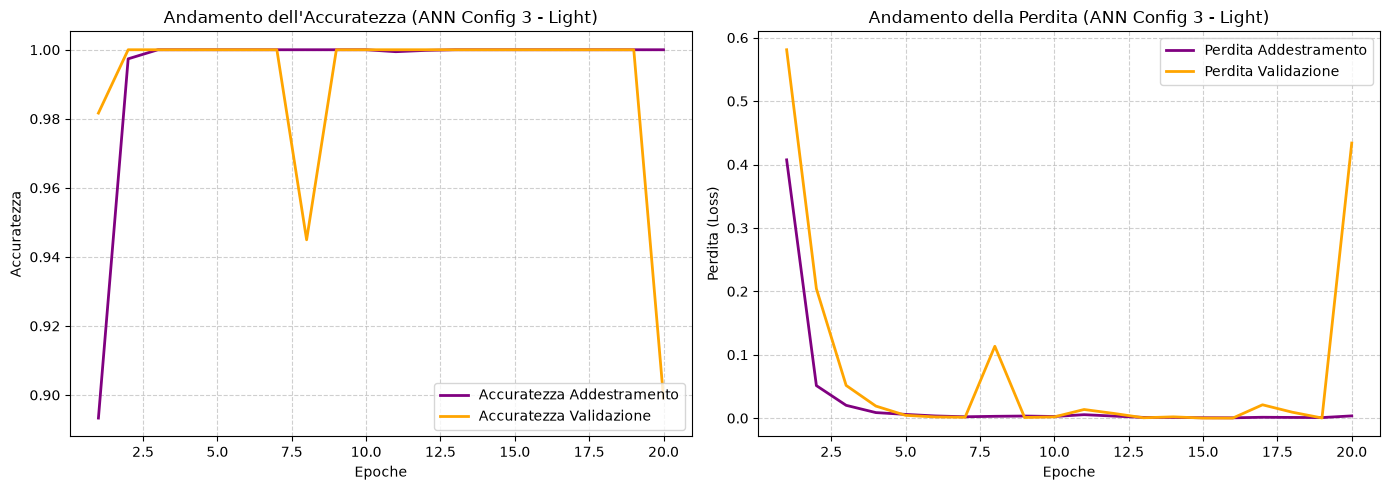

In [14]:
import matplotlib.pyplot as plt

# Estrazione dei dati dalla storia dell'addestramento della Configurazione 3
acc_3 = history_ann_3.history['accuracy']
val_acc_3_list = history_ann_3.history['val_accuracy']
loss_3 = history_ann_3.history['loss']
val_loss_3 = history_ann_3.history['val_loss']

epochs_range = range(1, len(acc_3) + 1)

# Creazione della figura con due grafici affiancati
plt.figure(figsize=(14, 5))

# Grafico 1: Accuratezza (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_3, label='Accuratezza Addestramento', color='purple', linewidth=2)
plt.plot(epochs_range, val_acc_3_list, label='Accuratezza Validazione', color='orange', linewidth=2)
plt.title('Andamento dell\'Accuratezza (ANN Config 3 - Light)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_3, label='Perdita Addestramento', color='purple', linewidth=2)
plt.plot(epochs_range, val_loss_3, label='Perdita Validazione', color='orange', linewidth=2)
plt.title('Andamento della Perdita (ANN Config 3 - Light)', fontsize=12)
plt.xlabel('Epoche')
plt.ylabel('Perdita (Loss)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()